- Mean imputation is used when the data is normall distributed.
- Median imputation is used when the data is skewed.


## Mean Imputation

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
data = {
    'Age' : [10,3,44,None,29,28,40,73,92,55],
    'height':[167,154,134,178,165,155,137,160,169,170]
}

In [61]:
df = pd.DataFrame(data)

In [62]:
df.head()

,Age,height
0,10.0,167
1,3.0,154
2,44.0,134
3,NaN,178
4,29.0,165


<Axes: >

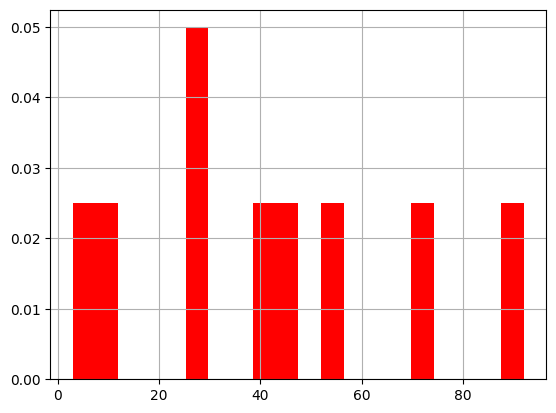

In [63]:
fig = plt.figure()
ax = fig.add_subplot()

df['Age'].hist(bins = 20, density = True, ax = ax, color = 'red')


<Axes: >

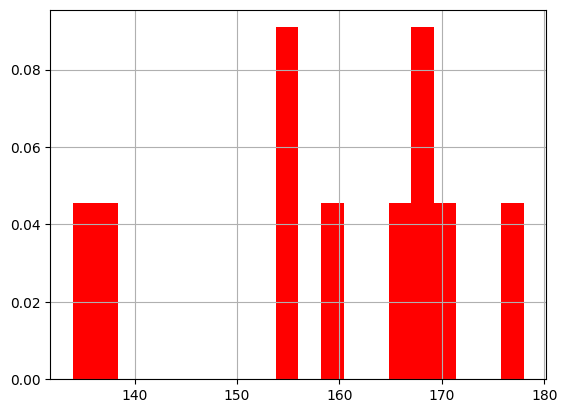

In [64]:
fig = plt.figure()
ax = fig.add_subplot()

df['height'].hist(bins = 20, density = True, ax = ax, color = 'red')


In [65]:
# Imputation

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [67]:
X = df.drop(columns=['height'])
y = df['height']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 2)

In [69]:
X_train

,Age
5,28.0
0,10.0
7,73.0
2,44.0
3,NaN
6,40.0
9,55.0
8,92.0


In [70]:
X_test

,Age
4,29.0
1,3.0


In [71]:
y_train

5    155
0    167
7    160
2    134
3    178
6    137
9    170
8    169
Name: height, dtype: int64

In [72]:
y_test

4    165
1    154
Name: height, dtype: int64

In [ ]:
df.isna().mean()*100  # 10% data is missing in Age column

Age       10.0
height     0.0
dtype: float64

In [80]:
X_train.isnull().mean()

Age    0.125
dtype: float64

In [82]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

In [83]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Age_median'] = X_train['Age'].fillna(median_age)

In [84]:
X_train

,Age,Age_mean,Age_median
5,28.0,28.000000,28.0
0,10.0,10.000000,10.0
7,73.0,73.000000,73.0
2,44.0,44.000000,44.0
3,NaN,48.857143,44.0
6,40.0,40.000000,40.0
9,55.0,55.000000,55.0
8,92.0,92.000000,92.0


In [85]:
print("Original Age variable Variance : ", X_train['Age'].var())
print("Age variable Variance After Mean Imputation: ", X_train['Age_mean'].var())
print("Age variable Variance After Median Imputation: ", X_train['Age_median'].var())


Original Age variable Variance :  754.8095238095239
Age variable Variance After Mean Imputation:  646.9795918367347
Age variable Variance After Median Imputation:  649.9285714285714


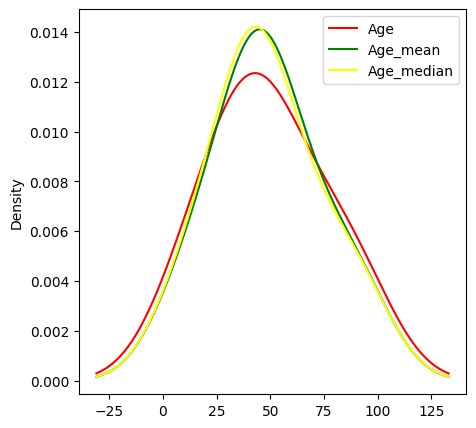

In [103]:
fig = plt.figure(figsize= (5,5))
ax = fig.add_subplot(111)

X_train['Age'].plot(kind = 'kde', ax = ax, color = 'Red')

X_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'green')

X_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'yellow')

lines, lables = ax.get_legend_handles_labels()
ax.legend(lines, lables, loc = 'best')

In [ ]:
# We have seen the distribution after mean imputation and Median imputation is increased at center

# Distribution should be same after and before the imputation.

In [105]:
X_train.corr()

,Age,Age_mean,Age_median
Age,1.0,1.000000,1.000000
Age_mean,1.0,1.000000,0.997729
Age_median,1.0,0.997729,1.000000


In [106]:
X_train.cov()

,Age,Age_mean,Age_median
Age,754.809524,754.809524,754.809524
Age_mean,754.809524,646.979592,646.979592
Age_median,754.809524,646.979592,649.928571


<Axes: >

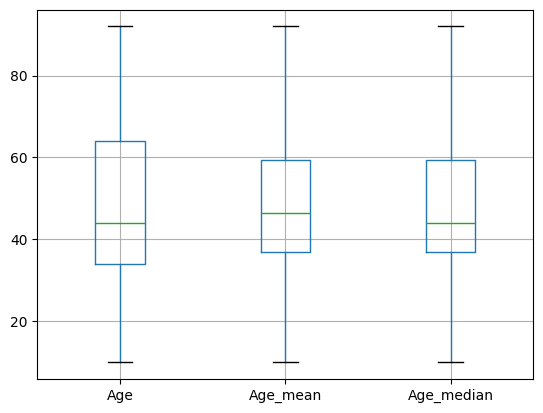

In [109]:
X_train[['Age','Age_mean', 'Age_median']].boxplot()